# 📘 Customer Churn & CLTV Prediction — Full Data Science Notebook
This notebook includes:
- Data Loading
- Full EDA
- Feature Engineering
- Churn Model
- CLTV Model
- Visualizations
- Final Insights


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries Loaded Successfully!')

Libraries Loaded Successfully!


## 📂 Load Input Files

In [3]:
customers = pd.read_csv('../inputs/customers.csv', parse_dates=['signup_date'])
transactions = pd.read_csv('../inputs/transactions.csv', parse_dates=['transaction_date'])
events = pd.read_csv('../inputs/events.csv', parse_dates=['event_date'])
support = pd.read_csv('../inputs/support.csv', parse_dates=['ticket_date'])

customers.head()

,customer_id,signup_date,plan,monthly_fee,recency_days,churn
0,1,2023-02-05,premium,40.0,108,0
1,2,2021-09-06,basic,10.0,165,1
2,3,2023-05-14,basic,10.0,132,0
3,4,2021-12-13,basic,10.0,111,0
4,5,2021-08-12,standard,20.0,15,0


## 📏 Dataset Shapes

In [4]:
print('Customers:', customers.shape)
print('Transactions:', transactions.shape)
print('Events:', events.shape)
print('Support:', support.shape)

Customers: (3000, 6)
Transactions: (51350, 3)
Events: (107842, 3)
Support: (454, 4)


## ❗ Missing Values

In [5]:
for name, df in [('Customers', customers),
                 ('Transactions', transactions),
                 ('Events', events),
                 ('Support', support)]:
    print(f'--- {name} ---')
    print(df.isnull().sum(), '\n')

--- Customers ---
customer_id     0
signup_date     0
plan            0
monthly_fee     0
recency_days    0
churn           0
dtype: int64 

--- Transactions ---
customer_id         0
transaction_date    0
amount              0
dtype: int64 

--- Events ---
customer_id    0
event_date     0
event_type     0
dtype: int64 

--- Support ---
customer_id        0
ticket_date        0
issue_type         0
resolution_days    0
dtype: int64 



## 📊 Exploratory Data Analysis

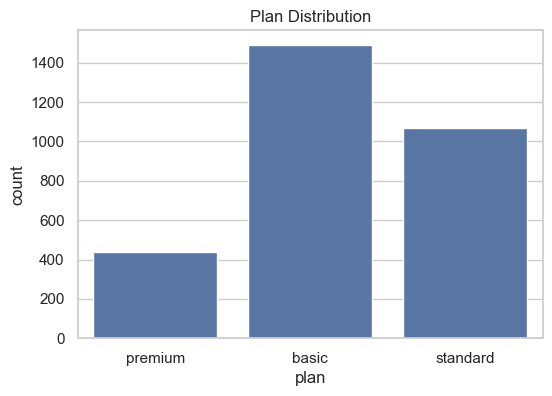

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=customers, x='plan')
plt.title('Plan Distribution')
plt.show()

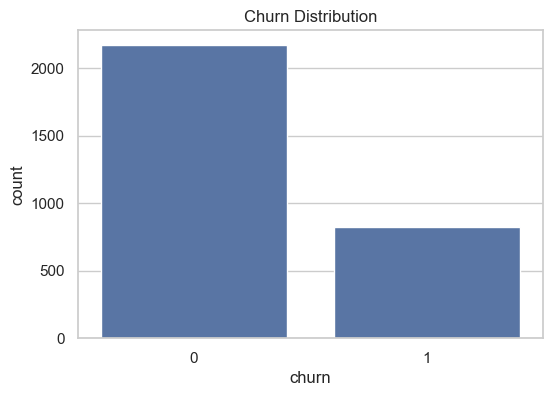

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=customers, x='churn')
plt.title('Churn Distribution')
plt.show()

## 🧮 Transaction-Based Features

In [8]:
trans_agg = transactions.groupby('customer_id').agg(
    total_spend=('amount','sum'),
    trans_count=('amount','count'),
    last_transaction=('transaction_date','max')
).reset_index()
trans_agg.head()

,customer_id,total_spend,trans_count,last_transaction
0,1,440.0,11,2023-12-06
1,2,280.0,28,2023-12-04
2,3,70.0,7,2023-11-19
3,4,230.0,23,2023-10-09
4,5,580.0,29,2023-12-01


## 🔐 Engagement Features (Logins)

In [9]:
ref_date = customers['signup_date'].max() + pd.Timedelta(days=365)
events['days_from_ref'] = (ref_date - events['event_date']).dt.days

login_7 = events[events['days_from_ref'] <= 7].groupby('customer_id').size().rename('logins_7d')
login_30 = events[events['days_from_ref'] <= 30].groupby('customer_id').size().rename('logins_30d')
login_90 = events[events['days_from_ref'] <= 90].groupby('customer_id').size().rename('logins_90d')

logins = pd.concat([login_7, login_30, login_90], axis=1).fillna(0).reset_index()
logins.head()

,customer_id,logins_7d,logins_30d,logins_90d


## 🛠 Support Features

In [10]:
support_agg = support.groupby('customer_id').agg(
    tickets=('issue_type','count'),
    avg_resolution=('resolution_days','mean')
).reset_index()
support_agg.head()

,customer_id,tickets,avg_resolution
0,3,1,1.0
1,8,1,2.0
2,10,1,9.0
3,12,1,4.0
4,16,1,4.0


## 🔄 Merge All Features

In [11]:
df = customers.merge(trans_agg, on='customer_id', how='left')
df = df.merge(logins, on='customer_id', how='left')
df = df.merge(support_agg, on='customer_id', how='left')
df = df.fillna(0)
df.head()

,customer_id,signup_date,plan,monthly_fee,recency_days,churn,total_spend,trans_count,last_transaction,logins_7d,logins_30d,logins_90d,tickets,avg_resolution
0,1,2023-02-05,premium,40.0,108,0,440.0,11,2023-12-06,0.0,0.0,0.0,0.0,0.0
1,2,2021-09-06,basic,10.0,165,1,280.0,28,2023-12-04,0.0,0.0,0.0,0.0,0.0
2,3,2023-05-14,basic,10.0,132,0,70.0,7,2023-11-19,0.0,0.0,0.0,1.0,1.0
3,4,2021-12-13,basic,10.0,111,0,230.0,23,2023-10-09,0.0,0.0,0.0,0.0,0.0
4,5,2021-08-12,standard,20.0,15,0,580.0,29,2023-12-01,0.0,0.0,0.0,0.0,0.0


## 🔥 Correlation Analysis

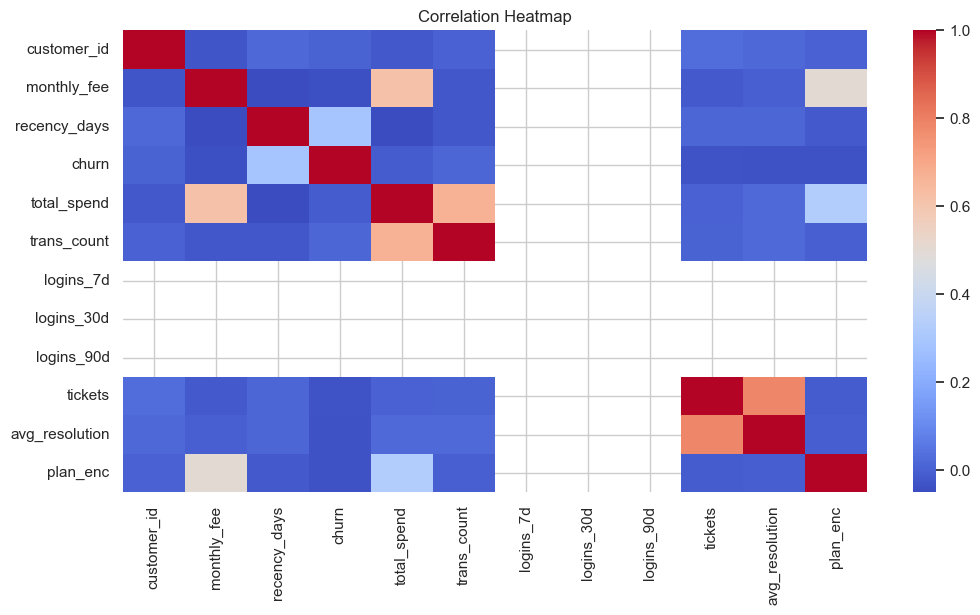

In [13]:
df_corr = df.copy()
df_corr['plan_enc'] = LabelEncoder().fit_transform(df_corr['plan'])
df_corr = df_corr.select_dtypes(include=[np.number])
plt.figure(figsize=(12,6))
sns.heatmap(df_corr.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

# 🤖 Churn Model Development

In [14]:
le = LabelEncoder()
df['plan_enc'] = le.fit_transform(df['plan'])

features = [
    'monthly_fee','recency_days','total_spend','trans_count',
    'logins_7d','logins_30d','logins_90d','tickets','avg_resolution','plan_enc'
]

X = df[features]
y = df['churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

churn_model = RandomForestClassifier(n_estimators=300, random_state=42)
churn_model.fit(X_train, y_train)

y_pred = churn_model.predict(X_test)
y_prob = churn_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.74      0.84      0.79       544
           1       0.36      0.24      0.29       206

    accuracy                           0.67       750
   macro avg       0.55      0.54      0.54       750
weighted avg       0.64      0.67      0.65       750

ROC-AUC: 0.6079963235294119


## 🔍 Churn Model Feature Importance

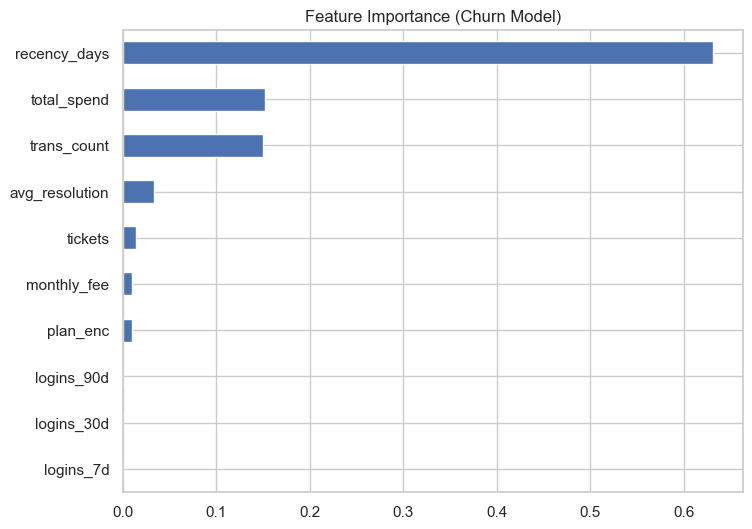

In [15]:
imp = pd.Series(churn_model.feature_importances_, index=features)
imp.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance (Churn Model)')
plt.show()

# 💰 CLTV Model Development

In [16]:
df['cltv_label'] = df['total_spend'] * 1.5
X2 = df[features]
y2 = df['cltv_label']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

cltv_model = RandomForestRegressor(n_estimators=300, random_state=42)
cltv_model.fit(X2_train, y2_train)

preds = cltv_model.predict(X2_test)
rmse = mean_squared_error(y2_test, preds, squared=False)

print('CLTV RMSE:', rmse)

CLTV RMSE: 1.1213682119030566


C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 💾 Save Models

In [17]:
joblib.dump(churn_model, '../models/churn_model_notebook.pkl')
joblib.dump(cltv_model, '../models/cltv_model_notebook.pkl')
print('Models Saved Successfully')

Models Saved Successfully
